In [ ]:
## uncomment these if you upload this on google drive and mount the drive
# from google.colab import drive
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
# drive.mount('/content/gdrive', force_remount=True)

#### Q1. Loading Data

Run the below cell to load CIFAR-10 train and test data.
Answer the corresponding questions in the overleaf document

In [ ]:
## Define transforms to apply on images
transform = transforms.Compose(
    [transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])

## defining training and test data
train_data = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_data = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

\
## creating data loaders
batch_size = 4 ## set the batch size value
train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=2)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size, shuffle=False, num_workers=2)

## image labels in cifar 10
class_labels = classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

100%|██████████| 170M/170M [00:13<00:00, 12.4MB/s]


### Helper function
To display images in the training set

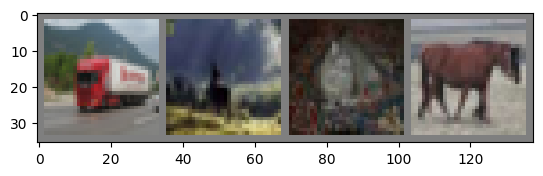

truck  deer   cat horse


In [ ]:
# function to display images in the training set
def display(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


## displaying images in 1 batch of the training set

# get 1 batch of training images
dataiter = iter(train_loader)
images, labels = next(dataiter)

# show images
display(torchvision.utils.make_grid(images[0:4]))
# print labels
print(' '.join('%5s' % class_labels[labels[j]] for j in range(4)))


### Q2. Classifier Architecture

In [ ]:
## Defining Classifier architecture

class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=6, kernel_size=5, stride=1, padding=0)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5, stride=1, padding=0)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 16 * 5 * 5)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

### Q3. Training the network

(i) Training on CPU

[1, 250] loss: 2.304
[1, 500] loss: 2.300
[1, 750] loss: 2.298
[1, 1000] loss: 2.290
[1, 1250] loss: 2.267
[1, 1500] loss: 2.202
[1, 1750] loss: 2.095
[1, 2000] loss: 2.037
[1, 2250] loss: 1.985
[1, 2500] loss: 1.948
[1, 2750] loss: 1.955
[1, 3000] loss: 1.867
[1, 3250] loss: 1.844
[1, 3500] loss: 1.793
[1, 3750] loss: 1.752
[1, 4000] loss: 1.763
[1, 4250] loss: 1.713
[1, 4500] loss: 1.714
[1, 4750] loss: 1.690
[1, 5000] loss: 1.678
[1, 5250] loss: 1.633
[1, 5500] loss: 1.664
[1, 5750] loss: 1.698
[1, 6000] loss: 1.647
[1, 6250] loss: 1.571
[1, 6500] loss: 1.604
[1, 6750] loss: 1.546
[1, 7000] loss: 1.559
[1, 7250] loss: 1.520
[1, 7500] loss: 1.523
[1, 7750] loss: 1.527
[1, 8000] loss: 1.504
[1, 8250] loss: 1.534
[1, 8500] loss: 1.485
[1, 8750] loss: 1.490
[1, 9000] loss: 1.536
[1, 9250] loss: 1.511
[1, 9500] loss: 1.476
[1, 9750] loss: 1.481
[1, 10000] loss: 1.397
[1, 10250] loss: 1.473
[1, 10500] loss: 1.449
[1, 10750] loss: 1.427
[1, 11000] loss: 1.424
[1, 11250] loss: 1.461
[1, 115

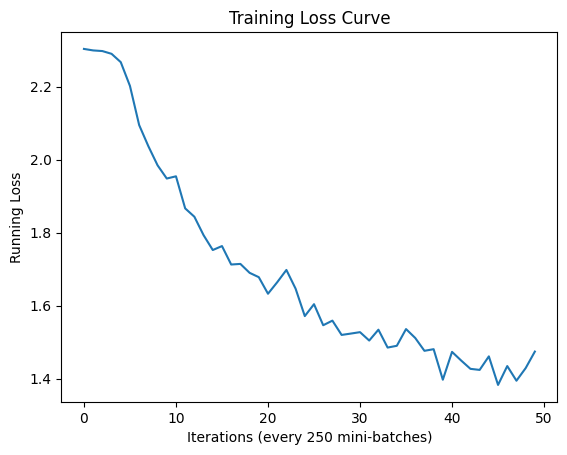

In [ ]:
### Complete the code in the training box

## for reproducibility
torch.manual_seed(7)
np.random.seed(7)

## Instantiating classifier
net = Net().cpu()

## Defining optimizer and loss function
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)


## Defining Training Parameters

num_epochs = 1 # 2 for CPU training, 10 for GPU training
running_loss_list = [] # list to store running loss in the code below
for epoch in range(num_epochs):  # loop over the dataset multiple times
    running_loss = 0.0
    for i, data in enumerate(train_loader, 0):
        # get the inputs; data is a list of [inputs, labels]
        inputs, labels = data
        inputs, labels = inputs.cpu(), labels.cpu()

        optimizer.zero_grad()
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # print statistics
        running_loss += loss.cpu().item()
        if i % 250 == 249:
          avg_loss = running_loss / 250
          print('[{}, {}] loss: {:.3f}'.format(epoch+1, i+1, avg_loss))
          running_loss_list.append(avg_loss)
          running_loss = 0.0


print('Training Complete')
PATH = './net.pth'
torch.save(net.state_dict(), PATH)

## complete the code to plot the running loss per 250 mini batches curve
def plot_loss_curve(running_loss_list):
    plt.plot(range(len(running_loss_list)), running_loss_list)
    plt.xlabel("Iterations (every 250 mini-batches)")
    plt.ylabel("Running Loss")
    plt.title("Training Loss Curve")
    plt.show()

plot_loss_curve(running_loss_list)


(ii) Paste the above code in the code block below and modify it to use GPUs for training


[1, 250] loss: 2.304
[1, 500] loss: 2.300
[1, 750] loss: 2.298
[1, 1000] loss: 2.290
[1, 1250] loss: 2.268
[1, 1500] loss: 2.203
[1, 1750] loss: 2.096
[1, 2000] loss: 2.037
[1, 2250] loss: 1.986
[1, 2500] loss: 1.947
[1, 2750] loss: 1.953
[1, 3000] loss: 1.862
[1, 3250] loss: 1.844
[1, 3500] loss: 1.791
[1, 3750] loss: 1.753
[1, 4000] loss: 1.765
[1, 4250] loss: 1.711
[1, 4500] loss: 1.718
[1, 4750] loss: 1.687
[1, 5000] loss: 1.682
[1, 5250] loss: 1.635
[1, 5500] loss: 1.672
[1, 5750] loss: 1.698
[1, 6000] loss: 1.643
[1, 6250] loss: 1.576
[1, 6500] loss: 1.600
[1, 6750] loss: 1.551
[1, 7000] loss: 1.559
[1, 7250] loss: 1.517
[1, 7500] loss: 1.526
[1, 7750] loss: 1.529
[1, 8000] loss: 1.509
[1, 8250] loss: 1.535
[1, 8500] loss: 1.486
[1, 8750] loss: 1.497
[1, 9000] loss: 1.529
[1, 9250] loss: 1.512
[1, 9500] loss: 1.475
[1, 9750] loss: 1.483
[1, 10000] loss: 1.396
[1, 10250] loss: 1.475
[1, 10500] loss: 1.461
[1, 10750] loss: 1.432
[1, 11000] loss: 1.426
[1, 11250] loss: 1.468
[1, 115

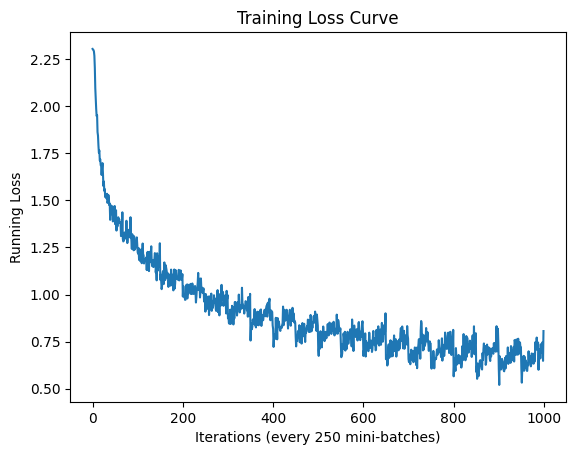

In [ ]:
### Copy the code from (i), and modify it to run on GPUs for 20 epochs
## for reproducibility
torch.manual_seed(7)
np.random.seed(7)

## Instantiating classifier (GPU)
net = Net().cuda()

## Defining optimizer and loss function
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

## Defining Training Parameters
num_epochs = 20
running_loss_list = []

for epoch in range(num_epochs):  # loop over dataset multiple times
    running_loss = 0.0

    for i, data in enumerate(train_loader, 0):
        # get inputs and labels
        inputs, labels = data

        # move to GPU
        inputs, labels = inputs.cuda(), labels.cuda()

        optimizer.zero_grad()

        outputs = net(inputs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        if i % 250 == 249:
            avg_loss = running_loss / 250
            print('[{}, {}] loss: {:.3f}'.format(epoch+1, i+1, avg_loss))
            running_loss_list.append(avg_loss)
            running_loss = 0.0

print('Training Complete')

PATH = './net.pth'
torch.save(net.state_dict(), PATH)

def plot_loss_curve(running_loss_list):
    plt.plot(range(len(running_loss_list)), running_loss_list)
    plt.xlabel("Iterations (every 250 mini-batches)")
    plt.ylabel("Running Loss")
    plt.title("Training Loss Curve")
    plt.show()

plot_loss_curve(running_loss_list)

### Testing the network

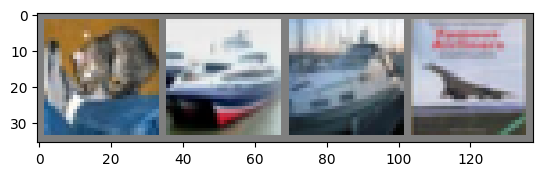

GroundTruth:    cat  ship  ship plane
Predicted:    cat  ship  ship plane


In [ ]:
## displaying images from test set
dataiter = iter(test_loader)
images, labels = next(dataiter)

# print images
display(torchvision.utils.make_grid(images[0:4]))
print('GroundTruth: ', ' '.join('%5s' % class_labels[labels[j]] for j in range(4)))

## Instantiating network and loading the trained model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

net = Net().to(device)
net.load_state_dict(torch.load(PATH))
net.eval()

## Getting predicted label/class from the model output
images_gpu = images.to(device)

outputs = net(images_gpu)
_, predicted = torch.max(outputs, 1)

print('Predicted: ', ' '.join('%5s' % class_labels[predicted[j]] for j in range(4)))

(iv) Complete the code below to test the network on the entire testing set.

In [ ]:
### Accuracy on whole data set
correct = 0
total = 0

with torch.no_grad():
    for data in test_loader:
        images, labels = data

        images, labels = images.to(device), labels.to(device)

        outputs = net(images)
        _, predicted = torch.max(outputs.data, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

acc = 100 * correct / total

print('Accuracy of the network on the 10000 test images: %d %%' % acc)

Accuracy of the network on the 10000 test images: 61 %


(v) Convert the training code in part (iii) and testing code in part (iv) to define functions `train` and  `test` with function definitions as shown below. Train the network with different batch size and number of epochs. Use the `plot_loss_curve` function you defined in (i) above to plot the loss curves. Use the defined `train` and `test` functions to train the network for various configurations asked in (v) in the problem set.

In [ ]:
def train(train_loader=train_loader, num_epochs=2, use_gpu=False, lr=0.001, momentum=0.9, model_save_path='./net.pth'):
  """
  INPUTS
  num_epochs: number of training epochs
  use_gpu: False by default. If true, load the model and data to GPU for training
  lr: learning rate for SGD optimizer
  momentum: momentum for SGD optimizer
  model_save_path: save path for the trained model

  OUTPUTS
  returns running_loss_list: which stores the loss averaged over a minibatch of size 250
  """

  ## complete the code.

  device = torch.device("cuda" if use_gpu and torch.cuda.is_available() else "cpu")

  net = Net().to(device)

  criterion = nn.CrossEntropyLoss()
  optimizer = optim.SGD(net.parameters(), lr=lr, momentum=momentum)

  running_loss_list = []

  net.train()

  for epoch in range(num_epochs):
      running_loss = 0.0

      for i, data in enumerate(train_loader):
          inputs, labels = data
          inputs, labels = inputs.to(device), labels.to(device)

          optimizer.zero_grad()
          outputs = net(inputs)
          loss = criterion(outputs, labels)
          loss.backward()
          optimizer.step()

          running_loss += loss.item()

          if i % 250 == 249:
              running_loss_list.append(running_loss / 250)
              running_loss = 0.0

  torch.save(net.state_dict(), model_save_path)

  return running_loss_list
def test(test_loader=test_loader, model_path='./net.pth'):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    net = Net().to(device)
    net.load_state_dict(torch.load(model_path))
    net.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for data in test_loader:
            images, labels = data
            images, labels = images.to(device), labels.to(device)

            outputs = net(images)
            _, predicted = torch.max(outputs.data, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    acc = 100 * correct / total
    print('Accuracy of the network on the 10000 test images: %d %%' % acc)

    return acc

Accuracy of the network on the 10000 test images: 61 %


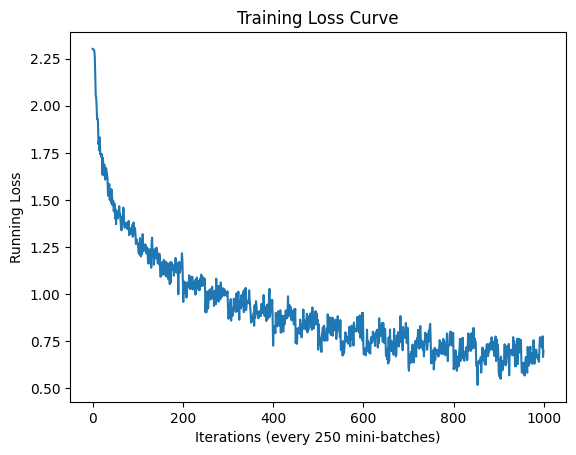

In [ ]:
#Experiment 1: Batch size = 4, Epochs = 20
train_loader = torch.utils.data.DataLoader(
    train_data, batch_size=4, shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    test_data, batch_size=4, shuffle=False
)

loss1 = train(train_loader=train_loader, num_epochs=20, use_gpu=True)
acc1 = test(test_loader=test_loader)

plot_loss_curve(loss1)

Accuracy of the network on the 10000 test images: 58 %


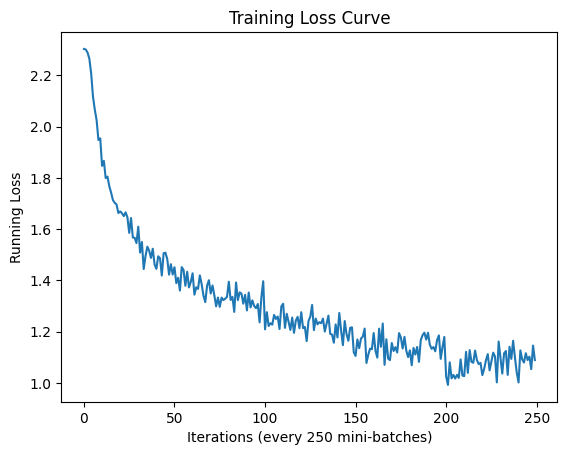

In [ ]:
#Experiment 2: Batch size = 4, Epochs = 5
train_loader = torch.utils.data.DataLoader(
    train_data, batch_size=4, shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    test_data, batch_size=4, shuffle=False
)

loss2 = train(train_loader=train_loader, num_epochs=5, use_gpu=True)
acc2 = test(test_loader=test_loader)

plot_loss_curve(loss2)

Accuracy of the network on the 10000 test images: 55 %


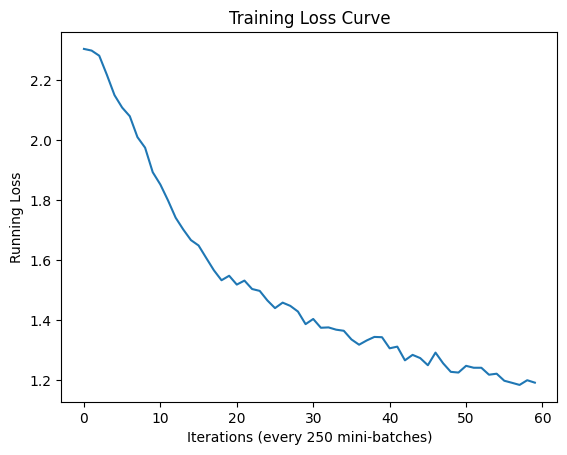

In [ ]:
#Experiment 3: Batch size = 16, Epochs = 5
train_loader = torch.utils.data.DataLoader(
    train_data, batch_size=16, shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    test_data, batch_size=16, shuffle=False
)

loss3 = train(train_loader=train_loader, num_epochs=5, use_gpu=True)
acc3 = test(test_loader=test_loader)

plot_loss_curve(loss3)

Accuracy of the network on the 10000 test images: 65 %


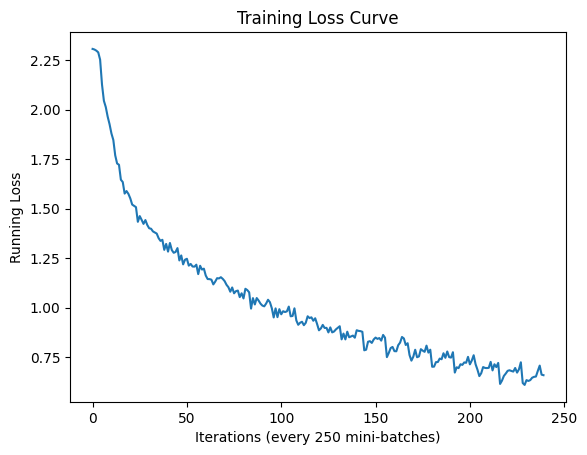

In [ ]:
#Experiment 4: Batch size = 16, Epochs = 20
train_loader = torch.utils.data.DataLoader(
    train_data, batch_size=16, shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    test_data, batch_size=16, shuffle=False
)

loss4 = train(train_loader=train_loader, num_epochs=20, use_gpu=True)
acc4 = test(test_loader=test_loader)

plot_loss_curve(loss4)

In [ ]:
print("Batch Size 4, Epochs 20:", acc1)
print("Batch Size 4, Epochs 5 :", acc2)
print("Batch Size 16, Epochs 5:", acc3)
print("Batch Size 16, Epochs 20:", acc4)

Batch Size 4, Epochs 20: 61.18
Batch Size 4, Epochs 5 : 58.05
Batch Size 16, Epochs 5: 55.46
Batch Size 16, Epochs 20: 65.68


In [ ]:
!pip install weasyprint
!apt-get install -y libpango-1.0-0 libpangoft2-1.0-0

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import subprocess
from google.colab import files
import weasyprint

notebook_name = "/content/drive/MyDrive/Colab Notebooks/hw4.ipynb"

subprocess.run(["jupyter", "nbconvert", "--to", "html", notebook_name])

html_name = notebook_name.replace(".ipynb", ".html")
pdf_name = notebook_name.replace(".ipynb", ".pdf")
weasyprint.HTML(filename=html_name).write_pdf(pdf_name)

files.download(pdf_name)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


.jp-scrollbar-tiny::-webkit-scrollbar-corner '
    --jp-terminal-icon-background-color,
    var(--jp-inverse-layout-color2)
  )` at 1557:3, unknown property.
      var(--jp-input-active-box-shadow-color),
    inset 0 0 0 3px var(--jp-input-active-box-shadow-color)` at 2783:3, unknown property.
input::placeholder ', unknown pseudo-element: placeholder
    inset 0 0 0 3px var(--jp-input-active-box-shadow-color)` at 3078:3, unknown property.
.lm-CommandPalette-input::-moz-placeholder,
.lm-CommandPalette-input:-ms-input-placeholder '
.cm-searching span::selection ', unknown pseudo-element: selection
.cm-searching > .jp-current-match::selection,
.jp-current-match > .cm-searching span::selection ', unknown pseudo-element: selection
    left,
    #f6f7f8 0%,
    #edeef1 20%,
    #f6f7f8 40%,
    #f6f7f8 100%
  )` at 6704:3, invalid value.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>